# New Models (v2)

This notebook repeats the cross-validation analysis from `02-First-Models.ipynb`, but uses the v2 structural feature set from `data/processed/structural-v1.csv`. The target is `log1_price`, so all losses and baseline comparisons below are on the log-price scale.

The learning-rate artifacts come from `configs/multiple/mlp-v2-learning-rates.toml`. The batch-size artifacts use the same v2 batch-size config values, stored under the separate experiment name `mlp-v2-batch-sizes` so the two sweeps do not overwrite each other.


In [1]:
from team_project.data.loading import (
    load_data_multi_run_cross_validation,
    load_cross_validation_mean_baseline,
    load_cross_validation_linear_baseline,
    load_final_metrics,
    load_final_mean_baseline,
    load_final_linear_baseline,
)
from team_project.visualization.plotting import plot_hyperparameter_runs

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
# Global aesthetic settings
plt.rcParams["figure.dpi"] = 120

sns.set_theme(
    style="ticks",
    font="sans-serif",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "xtick.direction": "out",
        "ytick.direction": "out",
    },
)


# Cross Validation

The plots below repeat the cross-validation checks from the first-model notebook. The model now uses structural and location features, categorical one-hot encoding, and the log-price target.


In [3]:
LR_EXPERIMENT = "mlp-v2-learning-rates"
BATCH_SIZE_EXPERIMENT = "mlp-v2-batch-sizes"

cv_multi_lr_data = load_data_multi_run_cross_validation(LR_EXPERIMENT)
cv_multi_batch_size_data = load_data_multi_run_cross_validation(BATCH_SIZE_EXPERIMENT)
cv_mean_baseline_metrics = load_cross_validation_mean_baseline(LR_EXPERIMENT)
cv_linear_baseline_metrics = load_cross_validation_linear_baseline(LR_EXPERIMENT)


In [4]:
def summarize_cv_runs(runs, hyperparameter_key, hyperparameter_name):
    rows = []
    for run in runs:
        training = run["metadata"]["training"]
        history = run["history"]
        rows.append({
            hyperparameter_name: training[hyperparameter_key],
            "final_val_mse": history["val_loss"][-1],
            "final_val_mse_std": history["val_loss_std"][-1],
            "best_epoch": pd.Series(history["val_loss"]).idxmin() + 1,
            "best_val_mse": min(history["val_loss"]),
        })
    return pd.DataFrame(rows).sort_values("final_val_mse")

lr_summary = summarize_cv_runs(cv_multi_lr_data, "lr", "learning_rate")
batch_size_summary = summarize_cv_runs(cv_multi_batch_size_data, "batch_size", "batch_size")

lr_summary


,learning_rate,final_val_mse,final_val_mse_std,best_epoch,best_val_mse
1,0.0010,0.302341,0.027015,24,0.299619
2,0.0100,0.325346,0.022049,12,0.306246
3,0.1000,0.435729,0.095505,15,0.402827
0,0.0001,0.466277,0.020411,25,0.466277


In [5]:
batch_size_summary


,batch_size,final_val_mse,final_val_mse_std,best_epoch,best_val_mse
1,64,0.331768,0.024112,24,0.316055
0,32,0.332079,0.031370,2,0.314920
2,128,0.348112,0.036593,21,0.311901
3,256,0.350509,0.037772,21,0.322429


In [6]:
best_lr_run = lr_summary.iloc[0]

cv_summary = pd.DataFrame([
    {
        "model": f"MLP v2, lr={best_lr_run['learning_rate']}",
        "mse": best_lr_run["final_val_mse"],
        "mse_std": best_lr_run["final_val_mse_std"],
    },
    {
        "model": "Mean baseline",
        "mse": cv_mean_baseline_metrics["mse"],
        "mse_std": cv_mean_baseline_metrics["mse_std"],
    },
    {
        "model": "Linear baseline",
        "mse": cv_linear_baseline_metrics["mse"],
        "mse_std": cv_linear_baseline_metrics["mse_std"],
    },
])

cv_summary


,model,mse,mse_std
0,"MLP v2, lr=0.001",0.302341,0.027015
1,Mean baseline,0.560679,0.035751
2,Linear baseline,0.296770,0.026777


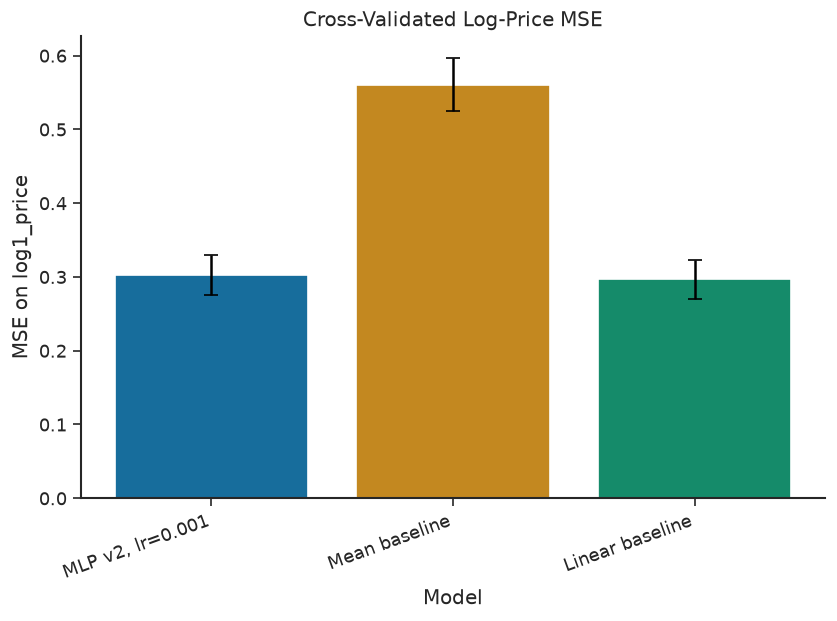

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cv_summary,
    x="model",
    y="mse",
    hue="model",
    palette="colorblind",
    legend=False,
)
plt.errorbar(
    x=range(len(cv_summary)),
    y=cv_summary["mse"],
    yerr=cv_summary["mse_std"],
    fmt="none",
    ecolor="black",
    capsize=4,
)
plt.title("Cross-Validated Log-Price MSE")
plt.xlabel("Model")
plt.ylabel("MSE on log1_price")
plt.xticks(rotation=20, ha="right")
sns.despine()
plt.show()


The v2 MLP clearly improves over the mean baseline. The linear baseline remains slightly stronger in this run, which suggests that the structural features are informative, but a plain MLP is not yet extracting much extra nonlinear signal.


## Cross-Validated Learning Rate Tuning


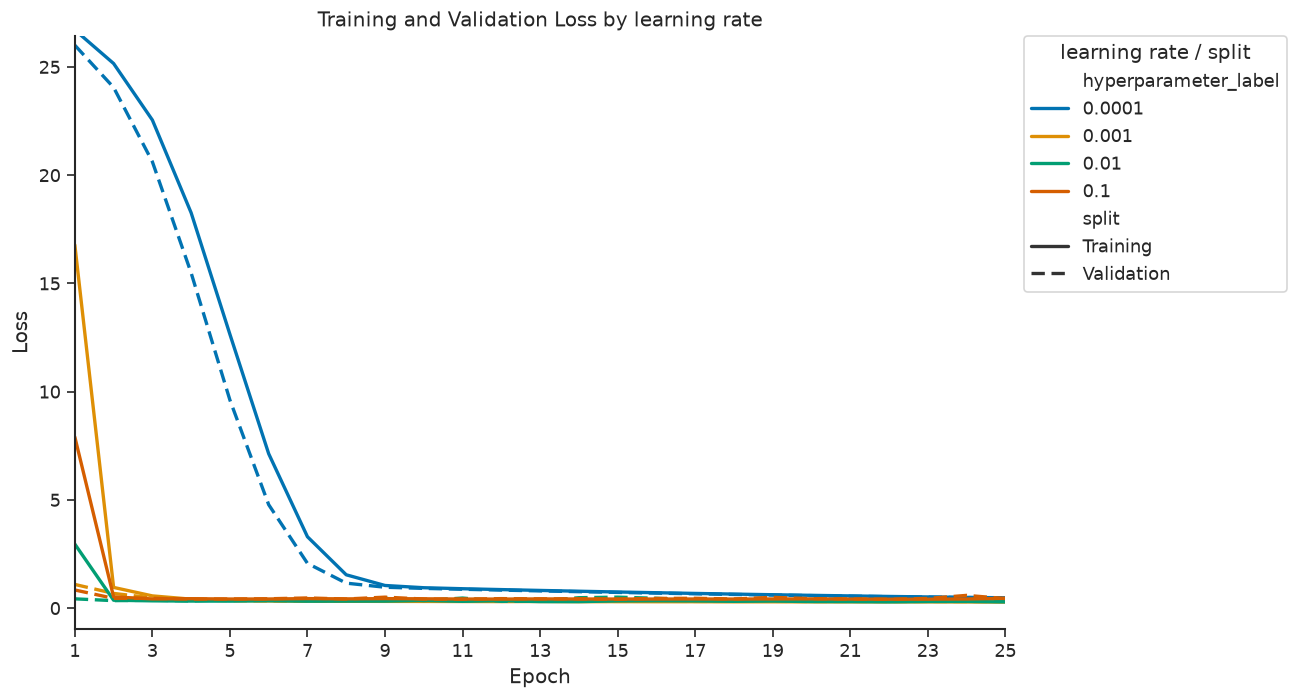

In [8]:
plot_hyperparameter_runs(cv_multi_lr_data, "lr", "learning rate")


The learning-rate sweep shows that `0.001` gives the best final validation loss. `0.0001` learns too slowly within 25 epochs, while the larger learning rates are less stable and finish worse.


## Cross-Validated Batch Size Tuning


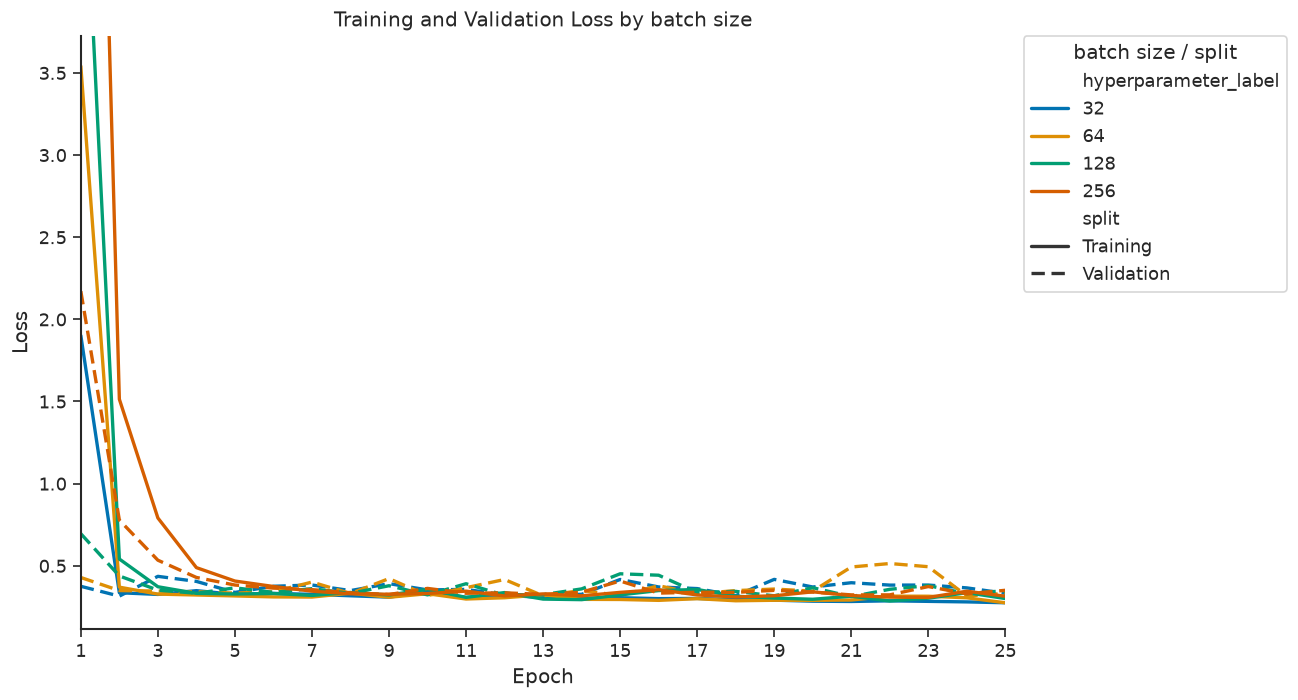

In [9]:
plot_hyperparameter_runs(cv_multi_batch_size_data, "batch_size", "batch size")


The batch-size sweep is much flatter than the learning-rate sweep. Batch sizes `32` and `64` are close, with `64` very slightly better in the final cross-validated validation loss.


## Takeaway

Compared with the first MLP, the v2 feature set is a real improvement: it beats the mean baseline by a wide margin on cross-validated log-price MSE. The linear baseline is still a little better, so the next modelling step should either tune the MLP architecture/regularization more carefully or compare against stronger tabular baselines such as ridge, random forest, or gradient boosting.


# Test Performance

After choosing the v2 setup from cross-validation, we train once on the full training split and compare final performance on the held-out test set. The metrics are still on the `log1_price` scale.


In [10]:
test_mlp_metrics = load_final_metrics("mlp-v2")
test_mean_baseline_metrics = load_final_mean_baseline("mlp-v2")
test_linear_baseline_metrics = load_final_linear_baseline("mlp-v2")

test_performance = pd.DataFrame([
    {"model": "MLP v2", **test_mlp_metrics},
    {"model": "Mean baseline", **test_mean_baseline_metrics},
    {"model": "Linear baseline", **test_linear_baseline_metrics},
])

test_performance = test_performance[["model", "mse", "rmse", "mae", "r2"]]
test_performance.round({
    "mse": 4,
    "rmse": 4,
    "mae": 4,
    "r2": 4,
})


,model,mse,rmse,mae,r2
0,MLP v2,0.2709,0.5205,0.3864,0.4747
1,Mean baseline,0.5163,0.7185,0.5719,-0.0012
2,Linear baseline,0.2707,0.5203,0.3838,0.4750


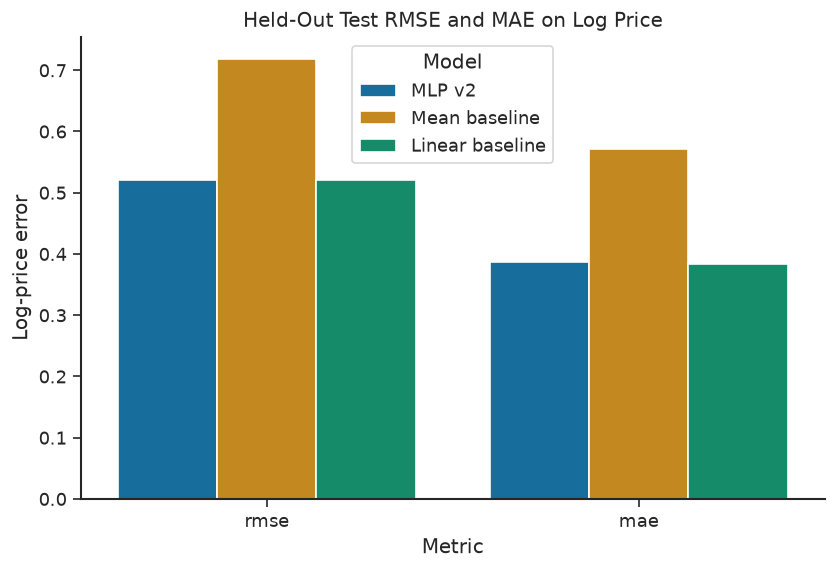

In [11]:
test_error_metrics = test_performance.melt(
    id_vars="model",
    value_vars=["rmse", "mae"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=test_error_metrics,
    x="metric",
    y="value",
    hue="model",
    palette="colorblind",
)
plt.title("Held-Out Test RMSE and MAE on Log Price")
plt.xlabel("Metric")
plt.ylabel("Log-price error")
plt.legend(title="Model")
sns.despine()
plt.show()


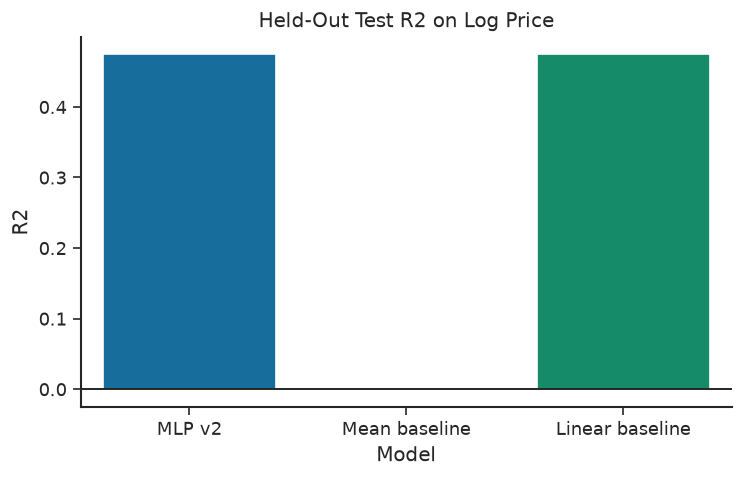

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=test_performance,
    x="model",
    y="r2",
    hue="model",
    palette="colorblind",
    legend=False,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Held-Out Test R2 on Log Price")
plt.xlabel("Model")
plt.ylabel("R2")
sns.despine()
plt.show()


The held-out test set confirms the cross-validation pattern. The v2 MLP is much better than the mean baseline, but it is effectively tied with the linear baseline on log-price error. That means the new structural features are doing useful work, while the current MLP architecture is not yet adding much beyond a linear model.
